# S02: Graph morphism in reaction informatics

## Aim of this talktorial

In **S01**, we built the foundations: **labeled molecular graphs** .

This talktorial (**S02**) moves to the *workhorse alignments* that appear throughout reaction modeling
and rule-based systems (e.g., Double Pushout graph rewriting):

1.  **isomorphisms** (exact equivalence),
2. **automorphisms** (internal symmetry).
3. **subgraph isomorphism**: finding when a *pattern* graph occurs inside a *host* graph
   via **labeled subgraph monomorphisms** (a.k.a. subgraph matching in practice).

We keep implementations minimal and transparent, using:

- **RDKit** for chemistry-aware substructure search (sanitization, aromaticity, valence) [[1]](#ref-1).
- **NetworkX** for explicit, attribute-based subgraph morphisms and symmetry-aware deduplication [[2]](#ref-2).

---

## Learning outcomes

After completing this talktorial, you will be able to:

- Formulate **labeled subgraph matching** as an **injective labeled graph morphism**
  $$
  \varphi : V(P) \hookrightarrow V(H),
  $$
- Compute **subgraph isomorphisms** (pattern → host) in **NetworkX**, and interpret multiple matches.
- Apply **symmetry-aware deduplication** of matches using automorphism or orbit ideas.
- Use **RDKit substructure matching** and understand when it differs from a pure graph matcher.
- Compute **MCS with RDKit** and turn it into an **alignment map** between two molecules.
- Compare **RDKit vs NetworkX** matching behavior and attribute choices, and decide which is appropriate for
  later steps (rule extraction, reaction center localization, DPO rule application).

---

## Outline

- [0. Setup & Data](#0-setup--data)
- [1. Graph isomorphism](#1-graph-isomorphism)
- [2. Graph automorphisms](#2-graph-automorphisms)
- [3. Subgraph isomorphism](#3-subgraph-isomorphism)
- [4. Discussion](#4-discussion)
- [5. Quiz](#5-quiz)
- [6. References](#6-references)

## 0. Setup & Data

In [1]:
import rdkit
import networkx as nx
import pandas as pd
from pathlib import Path
from synedu.Utils import draw_molecular_graph, mol_to_graph

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)

RDKit version: 2025.09.3
NetworkX version: 3.6.1


In [2]:
DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "molecules.csv"
df = pd.read_csv(CSV_PATH)
display(df)

,smiles,name
0,CCO,ethanol
1,CCCl,chloroethane
2,CCOCC,diethyl ether
3,O,water
4,NCC(=O)O,glycine
...,...,...
995,CNCC(O)c1ccc(O)cc1,oxedrine
996,Cc1nc(Nc2ccc(F)cc2)nc(N2CCc3ccccc3C2C)c1C,revaprazan
997,O=C(O)CCC(=O)c1ccc2c(c1)-c1cccc3cccc-2c13,florantyrone
998,COC(=O)CCC[N+](C)(C)C,carpronium


## 1. Graph isomorphism

To make “same molecule” precise, we model molecules as labeled graphs and compare them via
**label-preserving maps**. This section introduces **labeled graph morphisms** and the induced notion of
**graph isomorphism** [[3]](#ref-3)[[4]](#ref-4).

<figure style="text-align: center;">
  <img src="../../docs/_static/images/SO2/morphism.svg"
       alt="Graph morphism examples"
       style="width: 100%; max-width: 1000px;">
  <figcaption>
    <b>Figure 1.</b> Examples of graph morphism-related mappings: morphism,
    subgraph isomorphism, induced subgraph isomorphism, isomorphism,
    automorphism, and maximum common substructure.
  </figcaption>
</figure>

---

### 1.1 Graph morphisms

Let $G,H \in \mathcal{G}$ be labeled molecular graphs with atom/bond labeling functions
$(a_G,b_G)$ and $(a_H,b_H)$.

A **(labeled) graph morphism** from $G$ to $H$ is a map

$$
\varphi : V(G) \to V(H)
$$

that preserves atom types and bond structure. Concretely, for all $v \in V(G)$ and $uv \in E(G)$:

**(M1) Atom-label preservation**
$$
a_H(\varphi(v)) = a_G(v).
$$

**(M2) Adjacency preservation**
$$
\varphi(u)\varphi(v) \in E(H).
$$

**(M3) Bond-label preservation**
$$
b_H\!\big(\varphi(u)\varphi(v)\big) = b_G(uv).
$$

---

### 1.2 Graph isomorphism

Two labeled molecular graphs $G,H\in\mathcal{G}$ are **isomorphic**, written

$$
G \cong H,
$$

if there exists a **bijective** morphism

$$
\varphi : V(G) \to V(H)
$$

satisfying (M1)–(M3), whose inverse $\varphi^{-1}$ also satisfies (M1)–(M3).



> **Chemical intuition**  
> $G \cong H$ means the two graphs encode the *same chemical structure* up to a renumbering of atoms.

### 1.3. Practice

In practice, `networkx` tests $G \cong H$ by searching for such a bijection under the chosen
`node_match` / `edge_match`. The result therefore depends on the label scheme (and any compatibility rules).

$$
\Phi_V : V(G)\times V(H)\to\{\text{true},\text{false}\},
\qquad
\Phi_E : E(G)\times E(H)\to\{\text{true},\text{false}\},
$$

Throughout this talktorials, we use a *strict-but-minimal* label model:

- atom: `element`, `formal_charge`, `aromatic`,
- bond: `order`.

This keeps the equivalence relation explicit and reproducible; later notebooks revisit and relax these choices.


In [3]:
from rdkit import Chem
from networkx.algorithms import isomorphism as iso

pairs = {
    "benzene": ("c1ccccc1", "C1=CC=CC=C1"),
    "aniline": ("c1ccccc1N", "c1ccccc1[NH3+]"),
}

graphs = {}
for name, (sa, sb) in pairs.items():
    graphs[f"{name}_a"] = mol_to_graph(Chem.MolFromSmiles(sa))
    graphs[f"{name}_b"] = mol_to_graph(Chem.MolFromSmiles(sb))


def node_match(n1, n2):
    return n1.get("element") == n2.get("element")


def edge_match(e1, e2):
    return int(e1.get("order", 1)) == int(e2.get("order", 1))


def iso_and_count(G1, G2, nm, em):
    gm = iso.GraphMatcher(G1, G2, node_match=nm, edge_match=em)
    return gm.is_isomorphic(), sum(1 for _ in gm.isomorphisms_iter())


print("=== simple matcher (element + order) ===")
for name in pairs:
    G1 = graphs[f"{name}_a"]
    G2 = graphs[f"{name}_b"]
    iso_flag, n_maps = iso_and_count(G1, G2, node_match, edge_match)
    print(f"{name:8} | isomorphic: {int(iso_flag):1d} | mappings: {n_maps}")

=== simple matcher (element + order) ===
benzene  | isomorphic: 1 | mappings: 12
aniline  | isomorphic: 1 | mappings: 2


**Q1 — Isomorphism**

Implement `node_match` that requires matching `symbol` **and** either `hcount` or `formal_charge` (or both). Replace the existing `node_match` with your function and re-run the demo so that:

- `benzene` still matches, and  
- `aniline` (`c1ccccc1N`) **does not** match `anilinium` (`c1ccccc1[NH3+]`).

> Hint: `mol_to_graph(..., include_implicit_h=True)` stores H as `hcount`. Use `n.get("hcount",0)` or `n.get("formal_charge",0)`.

<details> <summary><b>Solution:</b></summary>

```python
def enhanced_node_match(n1, n2):
    return (
        n1.get("element") == n2.get("element")
        and (
            int(n1.get("hcount", 0)) == int(n2.get("hcount", 0))
            or int(n1.get("formal_charge", 0)) == int(n2.get("formal_charge", 0))
        )
    )

print("=== enhanced matcher (element + hcount/charge) ===")
for name in pairs:
    G1 = graphs[f"{name}_a"]; G2 = graphs[f"{name}_b"]
    iso_flag, n_maps = iso_and_count(G1, G2, enhanced_node_match, edge_match)
    print(f"{name:8} | isomorphic: {int(iso_flag):1d} | mappings: {n_maps}")

# quick instructor checks
assert iso_and_count(graphs["benzene_a"], graphs["benzene_b"], enhanced_node_match, edge_match)[0]
assert not iso_and_count(graphs["aniline_a"], graphs["aniline_b"], enhanced_node_match, edge_match)[0]
```

## 2. Graph automorphisms

### 2.1. Automorphsim

**Observation.** In the benzene example you enumerated **12 mappings** — these are the automorphisms of the benzene heavy-atom graph (the dihedral group \(D_6\), where \(|D_6| = 12\)).

**Definition.** An automorphism [[3]](#ref-3)[[4]](#ref-4) is a graph isomorphism from the graph to itself:

$$
f : G \longrightarrow G.
$$

The automorphism group is

$$
\mathrm{Aut}(G) \subseteq \mathrm{Iso}(G, G).
$$


[{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5},
 {0: 0, 5: 1, 4: 2, 3: 3, 2: 4, 1: 5},
 {1: 0, 0: 1, 5: 2, 4: 3, 3: 4, 2: 5},
 {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 0: 5},
 {2: 0, 1: 1, 0: 2, 5: 3, 4: 4, 3: 5},
 {2: 0, 3: 1, 4: 2, 5: 3, 0: 4, 1: 5},
 {3: 0, 2: 1, 1: 2, 0: 3, 5: 4, 4: 5},
 {3: 0, 4: 1, 5: 2, 0: 3, 1: 4, 2: 5},
 {4: 0, 3: 1, 2: 2, 1: 3, 0: 4, 5: 5},
 {4: 0, 5: 1, 0: 2, 1: 3, 2: 4, 3: 5},
 {5: 0, 0: 1, 1: 2, 2: 3, 3: 4, 4: 5},
 {5: 0, 4: 1, 3: 2, 2: 3, 1: 4, 0: 5}]

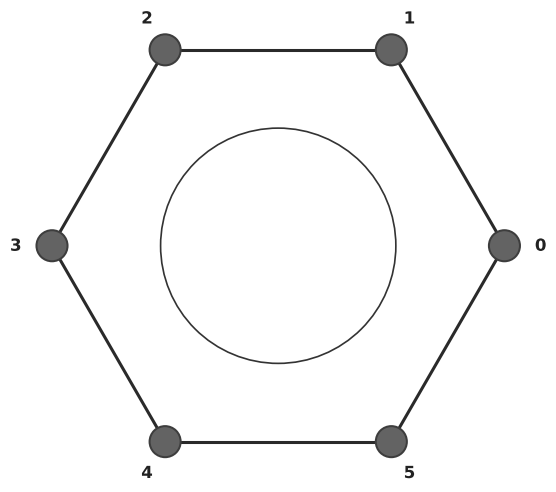

In [4]:
def node_match(n1, n2):
    return n1.get("element") == n2.get("element")


def edge_match(e1, e2):
    return int(e1.get("order", 1)) == int(e2.get("order", 1))


def enumerate_automorphisms(G: nx.Graph):
    GM_self = iso.GraphMatcher(G, G, node_match=node_match, edge_match=edge_match)
    return list(GM_self.isomorphisms_iter())


smiles = 'c1ccccc1'
mol = Chem.MolFromSmiles(smiles)
graph = mol_to_graph(mol)
draw_molecular_graph(graph, show_indices=True)
enumerate_automorphisms(graph)

### Automorphism group as permutation matrices

Each automorphism $\sigma \in \mathrm{Aut}(G)$ is a bijection $\sigma: V \to V$.
We represent it as a **permutation matrix** $P_\sigma \in \{0,1\}^{|V| \times |V|}$
where $P_\sigma[i,j] = 1$ iff $\sigma(v_i) = v_j$.

For benzene the full group has order $|\mathrm{Aut}(G)| = 12$ (dihedral group $D_6$).

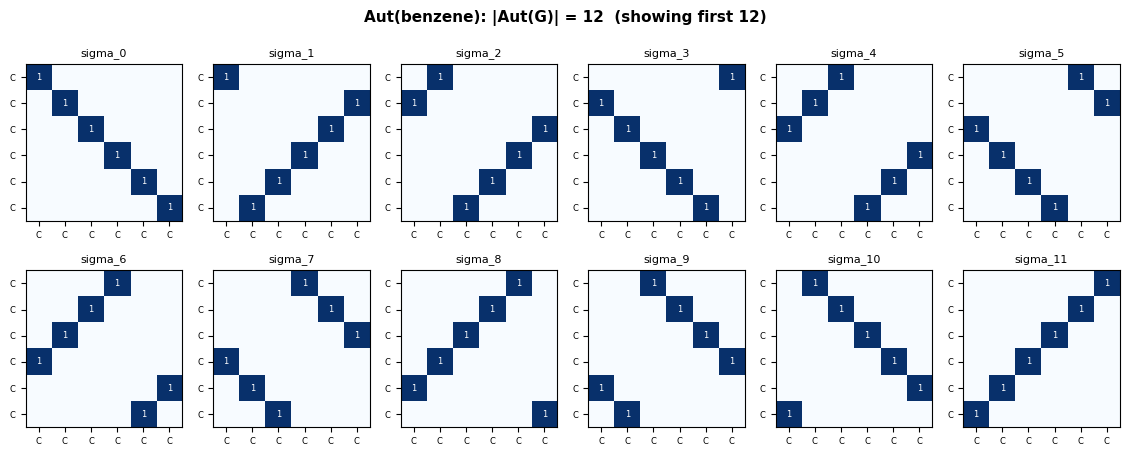

Benzene has 12 automorphisms


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from synedu.Utils import mol_to_graph
from networkx.algorithms.isomorphism import GraphMatcher


def _node_match_sym(n1, n2):
    return n1.get('element') == n2.get('element')


_mol = Chem.MolFromSmiles('c1ccccc1')  # benzene
_G = mol_to_graph(_mol)
_nodes = list(_G.nodes())
_gm = GraphMatcher(_G, _G, node_match=_node_match_sym)
_autos = list(_gm.isomorphisms_iter())

n = len(_nodes)
node_idx = {v: i for i, v in enumerate(_nodes)}
n_show = min(len(_autos), 12)
ncols = min(6, n_show)
nrows = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.9, nrows * 2.3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for k, sigma in enumerate(_autos[:n_show]):
    P = np.zeros((n, n), dtype=int)
    for src, dst in sigma.items():
        P[node_idx[src], node_idx[dst]] = 1
    ax = axes[k]
    ax.imshow(P, cmap='Blues', vmin=0, vmax=1, aspect='equal')
    elem = [_G.nodes[v].get('element', '?') for v in _nodes]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(elem, fontsize=6)
    ax.set_yticklabels(elem, fontsize=6)
    ax.set_title(f'sigma_{k}', fontsize=8)
    for i in range(n):
        for j in range(n):
            if P[i, j]:
                ax.text(j, i, '1', ha='center', va='center', fontsize=6, color='white')

for ax in axes[n_show:]:
    ax.axis('off')

fig.suptitle(
    f'Aut(benzene): |Aut(G)| = {len(_autos)}  (showing first {n_show})',
    fontsize=11,
    fontweight='bold',
)
plt.tight_layout()
plt.show()
print(f'Benzene has {len(_autos)} automorphisms')

**Q2 — Automorphism group**

Consider the molecular graph of **aniline** (`c1ccccc1N`).

1. Enumerate **all graph automorphisms** that preserve atom and bond labels.
2. Identify which atoms are **symmetry-equivalent** under these automorphisms.

<details>
<summary><b>Solution</b></summary>

```python
smiles = 'c1ccccc1N'
mol = Chem.MolFromSmiles(smiles)
graph = mol_to_graph(mol)

draw_molecular_graph(graph)
enumerate_automorphisms(graph)

```


### 3.2 Orbit

The **orbit** of an atom \(v\) is the set of atoms it can be mapped to by
molecular symmetries [[3]](#ref-3)[[4]](#ref-4):
$$
\mathrm{Orbit}(v)=\{\psi(v)\mid \psi\in\mathrm{Aut}(G)\}.
$$

Two atoms are **symmetry-equivalent** if one can be exchanged for the other
without changing the molecule:
$$
u \sim v
\;\Longleftrightarrow\;
\exists\,\varphi\in\mathrm{Aut}(G)\ \text{s.t.}\ \varphi(u)=v .
$$

**Chemical intuition.**  
Atoms in the same orbit are indistinguishable by connectivity alone—they
share the same local environment and chemical role.

**Benzene example.**
$$
|\mathrm{Aut}(G)| = |D_6| = 12,
$$
and all six carbon atoms form a **single orbit**.

**Why it matters.**  
Orbits identify symmetry-equivalent atoms, enabling symmetry-aware
deduplication, canonical mappings, and reduced search in subgraph matching.


In [6]:
import networkx as nx
from typing import Dict, Iterable, List, Set, Hashable


def compute_orbits_from_automorphisms(
    G: nx.Graph,
    automorphisms: Iterable[Dict[Hashable, Hashable]] | None = None,
) -> List[Set[Hashable]]:
    """
    Compute vertex orbits induced by graph automorphisms.

    Vertices belong to the same orbit if an automorphism maps one to the
    other. In molecular graphs, each orbit represents symmetry-equivalent
    atoms.

    :param G:
        Input graph.
    :type G: nx.Graph
    :param automorphisms:
        Iterable of automorphisms ``{v: φ(v)}``. If ``None``,
        automorphisms are computed internally.
    :type automorphisms: iterable of dict, optional
    :returns:
        List of vertex orbits (sets of nodes), deterministically ordered.
    :rtype: list[set]
    """
    ...

    if automorphisms is None:
        automorphisms = enumerate_automorphisms(G)

    # --- Union–find (disjoint set) ---
    parent: Dict[Hashable, Hashable] = {v: v for v in G.nodes()}

    def find(x: Hashable) -> Hashable:
        """Find set representative with path compression."""
        if parent[x] != x:
            parent[x] = find(parent[x])
        return parent[x]

    def union(a: Hashable, b: Hashable) -> None:
        """Merge the sets containing a and b."""
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    # --- Apply automorphism action ---
    for auto in automorphisms:
        for v, fv in auto.items():
            union(v, fv)

    # --- Collect orbits ---
    orbits: Dict[Hashable, Set[Hashable]] = {}
    for v in G.nodes():
        r = find(v)
        orbits.setdefault(r, set()).add(v)

    return sorted(orbits.values(), key=lambda s: min(s))

In [7]:
autos = enumerate_automorphisms(graph)
orbits = compute_orbits_from_automorphisms(graph, autos)

print("Number of automorphisms (benzene):", len(autos))
print("Orbits:", orbits)

Number of automorphisms (benzene): 12
Orbits: [{0, 1, 2, 3, 4, 5}]


### Orbit coloring

Nodes are coloured by orbit index — atoms of the same colour are **symmetry-equivalent** under $\mathrm{Aut}(G)$.
Breaking symmetry (a methyl group, a chiral centre) splits large orbits into smaller ones.

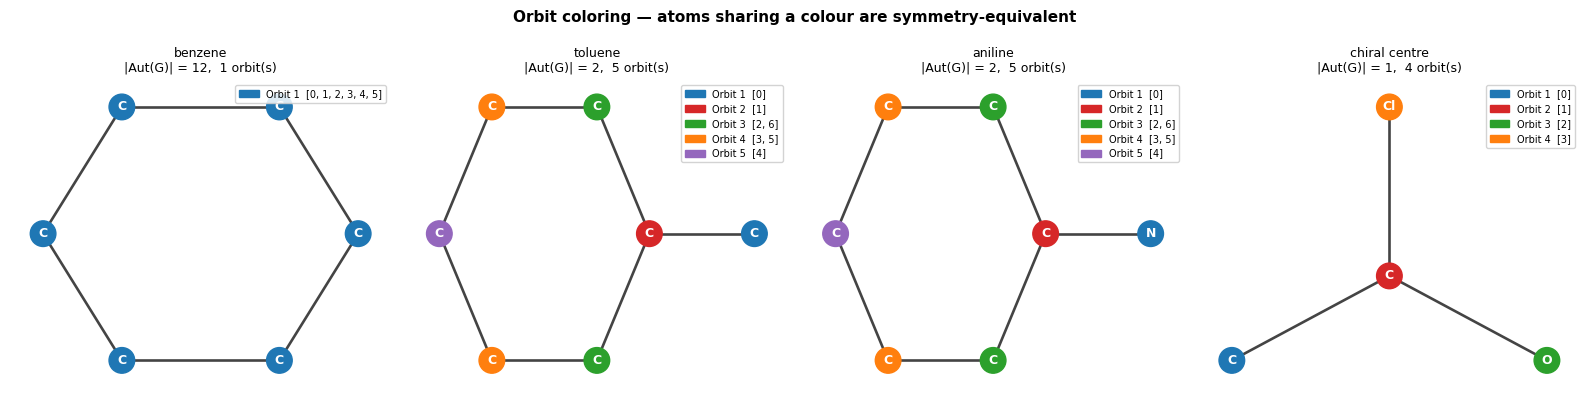

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from rdkit import Chem
from rdkit.Chem import AllChem
from synedu.Utils import mol_to_graph

_ORBIT_PAL = [
    "#1F77B4",
    "#D62728",
    "#2CA02C",
    "#FF7F0E",
    "#9467BD",
    "#8C564B",
    "#E377C2",
    "#17BECF",
]


def _orbit_colors(G):
    autos_ = enumerate_automorphisms(G)
    orbits_ = compute_orbits_from_automorphisms(G, autos_)
    node_orbit = {}
    for i, orb in enumerate(sorted(orbits_, key=min)):
        for n in orb:
            node_orbit[n] = i
    return node_orbit, orbits_, autos_


def draw_orbit_graph(G, mol, title, ax):
    node_orbit, orbits_, autos_ = _orbit_colors(G)
    colors = [_ORBIT_PAL[node_orbit[n] % len(_ORBIT_PAL)] for n in sorted(G.nodes())]

    AllChem.Compute2DCoords(mol)
    conf = mol.GetConformer()
    pos = {n: (conf.GetAtomPosition(n).x, conf.GetAtomPosition(n).y) for n in G.nodes()}

    nx.draw_networkx(
        G,
        pos=pos,
        ax=ax,
        node_color=colors,
        node_size=340,
        labels={n: G.nodes[n].get("element", "C") for n in G.nodes()},
        font_color="white",
        font_size=9,
        font_weight="bold",
        edge_color="#444",
        width=1.9,
        with_labels=True,
    )

    patches = [
        mpatches.Patch(
            color=_ORBIT_PAL[i % len(_ORBIT_PAL)],
            label=f"Orbit {i+1}  {sorted(sorted(orbits_, key=min)[i])}",
        )
        for i in sorted(set(node_orbit.values()))
    ]
    ax.legend(handles=patches, fontsize=7, loc="upper right", framealpha=0.85)
    ax.set_title(
        f"{title}\n|Aut(G)| = {len(autos_)},  {len(orbits_)} orbit(s)", fontsize=9
    )
    ax.axis("off")


examples = [
    ("benzene", "c1ccccc1"),
    ("toluene", "Cc1ccccc1"),
    ("aniline", "Nc1ccccc1"),
    ("chiral centre", "C[C@H](O)Cl"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    "Orbit coloring — atoms sharing a colour are symmetry-equivalent",
    fontsize=11,
    fontweight="bold",
)
for ax, (name, smi) in zip(axes, examples):
    mol_ = Chem.MolFromSmiles(smi)
    G_ = mol_to_graph(mol_)
    draw_orbit_graph(G_, mol_, name, ax)
plt.tight_layout()
plt.show()

**Q3 - Orbits**

You have computed the automorphisms and orbits for **benzene**, where all
carbons fall into a single orbit.

**Goal.** Explore how small chemical changes break symmetry and split orbits.

**Tasks.**
1. Starting from the benzene example, **modify only the SMILES input** to:
   - pyridine: `c1ccncc1`
   - toluene: `Cc1ccccc1`
2. Re-run the same code and record:
   - the number of automorphisms,
   - the number of orbits,
   - the atoms in each orbit.
3. Compare the results to benzene.

## 3. Subgraph isomorphism

In rule-based reaction modeling, we repeatedly solve the **pattern-in-host** query:

$$
\text{Does a pattern graph } P \text{ occur inside a host graph } G?
\quad \text{If yes, what are the embeddings?}
$$

Formally, a **subgraph isomorphism** [[3]](#ref-3)[[4]](#ref-4) is an **injective, label-preserving graph morphism**

$$
f : V(P) \hookrightarrow V(G)
$$

such that:

- **Atom (node) labels are preserved**
  $$a_G(f(v)) = a_P(v)\quad \forall v \in V(P)$$

- **Bond existence and bond types are preserved**
  $$uv \in E(P)\ \Rightarrow\ f(u)f(v) \in E(G), \quad b_G(f(u)f(v)) = b_P(uv)$$

Intuitively, \(f\) is a **labeled monomorphism**: it embeds the pattern into the host
without collisions (injective), while respecting chemical identity (types).


### 3.1. NetworkX subgraph match

NetworkX exposes this via:

- `GraphMatcher.subgraph_isomorphisms_iter()` — enumerates all injective embeddings
  that satisfy `node_match` and `edge_match`.

For downstream tasks (reaction center extraction, rule application, deduplication),
we often need to **post-process** these matches to remove symmetry-equivalent
embeddings, typically by orbit-based canonicalization or choosing a canonical
representative embedding.

In [9]:
from __future__ import annotations
from typing import Dict, List
import networkx as nx
from networkx.algorithms import isomorphism as iso
from rdkit import Chem


def nx_subgraph_matches(
    host_G: nx.Graph,
    pattern_G: nx.Graph,
    *,
    invert: bool = True,
) -> List[Dict]:
    """
    Enumerate subgraph isomorphisms of `pattern_G` inside `host_G`.

    Notes
    -----
    NetworkX's GraphMatcher(host, pattern).subgraph_isomorphisms_iter()
    yields mappings of the form:  host_node -> pattern_node  (G1 -> G2).

    If you want the more intuitive direction (pattern -> host), set `invert=True`.
    """
    GM = iso.GraphMatcher(
        host_G,
        pattern_G,
        node_match=node_match,
        edge_match=edge_match,
    )

    out: List[Dict] = []
    for m_host_to_pat in GM.subgraph_isomorphisms_iter():
        if invert:
            out.append({p: h for h, p in m_host_to_pat.items()})
        else:
            out.append(m_host_to_pat)
    return out


pattern_mol = Chem.MolFromSmiles("c1ccccc1")  # benzene
host_mol = Chem.MolFromSmiles("c1ccc2ccccc2c1")  # naphthalene

pattern_G = mol_to_graph(pattern_mol)
host_G = mol_to_graph(host_mol)

matches = nx_subgraph_matches(host_G, pattern_G, invert=True)  # pattern_idx -> host_idx

print("Raw subgraph isomorphisms (pattern -> host):", len(matches))

Raw subgraph isomorphisms (pattern -> host): 24


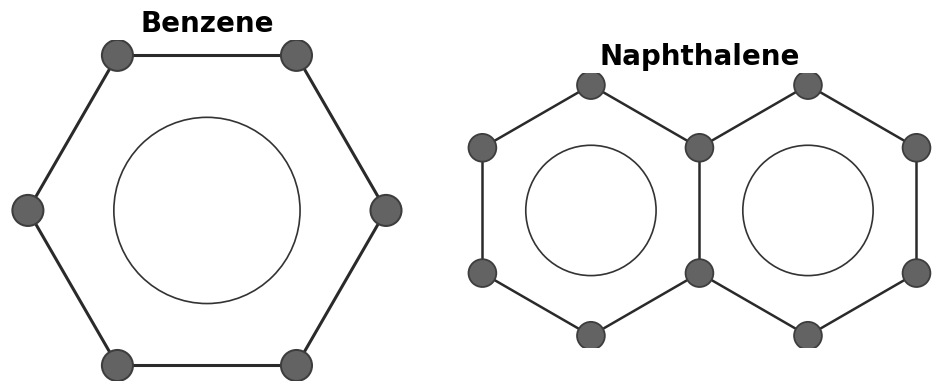

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

draw_molecular_graph(
    pattern_G,
    mol=pattern_mol,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[0].set_title("Benzene", fontsize=20, weight='bold')

draw_molecular_graph(
    host_G,
    mol=host_mol,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[1].set_title("Naphthalene", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

### Subgraph match gallery

Each panel highlights one **chemically distinct placement** of benzene inside naphthalene.
The 24 raw matches collapse to 2 unique placements after deduplication by host-atom image.

Even when the chemical occurrence is “the same”, symmetric graphs can admit many
equally valid embeddings.

For matching **benzene** \(P\) inside **naphthalene** \(G\), the algorithm reports
**24 matches**, arising purely from symmetry:

- **Host symmetry**: automorphisms of \(G\) create multiple placements.
- **Pattern symmetry**: automorphisms of \(P\) create equivalent labelings.
- **Combined effect**:
$$
\#\text{matches} \;\sim\; |\mathrm{Aut}(G)| \cdot |\mathrm{Aut}(P)|
$$

### 3.2. Deduplication of subgraph embeddings

We give a minimal, renderer-friendly description of the **host-image**
deduplication strategy.

Let
$$
m : V(P) \longrightarrow V(G)
$$
be a mapping from pattern nodes to host nodes.
The **image** of \( m \) is the set of host nodes occupied by the embedding:

$$
\mathrm{img}(m) = \{\, m(v) \mid v \in V(P) \,\} \subseteq V(G).
$$

We deduplicate embeddings by grouping all mappings that share the same image.
Operationally, we use the sorted tuple of \( \mathrm{img}(m) \) as a canonical key:

$$
\mathrm{key}(m) = \mathrm{tuple}\!\left(\mathrm{sorted}\big(\mathrm{img}(m)\big)\right).
$$

This collapses symmetry variants that differ only by permutations of pattern
nodes (i.e., different bijections with the same image) and yields the distinct
*placements* of the pattern inside the host.


In [11]:
from collections import defaultdict
from typing import Dict, Iterable, List, Mapping, Tuple, Union, Optional


def _build_node_to_rep(
    orbits: Union[Iterable[Iterable[int]], Mapping[int, int], None],
) -> Dict[int, int]:
    """Convert `orbits` into a mapping node -> representative."""
    if orbits is None:
        return {}
    if isinstance(orbits, Mapping):
        return dict(orbits)
    node_to_rep: Dict[int, int] = {}
    for orbit in orbits:
        orbit = set(orbit)
        if not orbit:
            continue
        rep = min(orbit)
        for v in orbit:
            node_to_rep[v] = rep
    return node_to_rep


def dedup_by_host_image_with_orbits(
    matches: Iterable[Dict[int, int]],
    *,
    orbits: Union[Iterable[Iterable[int]], Mapping[int, int], None] = None,
    pattern_node_order: Optional[Iterable[int]] = None,
    return_groups: bool = False,
) -> Union[List[Dict[int, int]], Dict[Tuple[int, ...], List[Dict[int, int]]]]:
    """
    Deduplicate pattern->host mappings by canonical host-image (with optional orbit reps).

    Parameters
    ----------
    matches : iterable of dict
        Each mapping is pattern_node -> host_node.
    orbits : iterable of iterables OR mapping node->rep OR None
        If iterable-of-iterables, representative for an orbit is min(orbit).
        If mapping, it should be node -> representative.
        If None, no orbit canonicalization is applied.
    pattern_node_order : iterable of pattern node ids, optional
        Order used to form the per-mapping tuple for selecting the representative.
        If None, inferred deterministically from the first mapping (sorted keys).
    return_groups : bool (default False)
        If False (default) return a list of representative mappings (one per canonical class).
        If True return the full dict: canonical_key -> list[mappings].

    Returns
    -------
    List[dict] or Dict[tuple, list]
        See `return_groups` description.
    """
    matches = list(matches)  # materialize to allow multiple passes
    if not matches:
        return {} if return_groups else []

    node_to_rep = _build_node_to_rep(orbits)

    # infer or validate pattern node order
    if pattern_node_order is None:
        # Use sorted keys of the first mapping (deterministic)
        pattern_node_order = tuple(sorted(matches[0].keys()))
    else:
        pattern_node_order = tuple(pattern_node_order)

    # bucket by canonical key (sorted canonicalized host nodes)
    buckets: Dict[Tuple[int, ...], List[Dict[int, int]]] = defaultdict(list)
    for m in matches:
        canonical_nodes = (node_to_rep.get(h, h) for h in m.values())
        key = tuple(sorted(canonical_nodes))
        buckets[key].append(m)

    # if user requested full groups, return them (deterministic ordering by key)
    if return_groups:
        return {k: buckets[k] for k in sorted(buckets.keys())}

    # otherwise pick a deterministic representative per bucket:
    # representative = mapping with smallest tuple (m[p] for p in pattern_node_order)
    representatives: List[Dict[int, int]] = []
    for key in sorted(buckets.keys()):
        group = buckets[key]

        # compute lexicographic tuple for each mapping according to pattern_node_order
        def ordering_tuple(m: Dict[int, int]) -> Tuple[int, ...]:
            return tuple(m[p] for p in pattern_node_order)

        rep = min(group, key=ordering_tuple)
        representatives.append(rep)

    return representatives

In [12]:
# 1. compute host orbits (optional — useful if you later want to collapse host symmetry)
host_autos = enumerate_automorphisms(host_G)  # φ : host_node -> host_node
host_orbits = compute_orbits_from_automorphisms(host_G, host_autos)  # list of sets
print("Host orbits:", host_orbits)
print()

# 2. dedup by host-image (default: returns representatives list)
representatives = dedup_by_host_image_with_orbits(matches)  # list of rep mappings
print("Number of representatives:", len(representatives))
for i, rep in enumerate(representatives, start=1):
    print(f" representative #{i}:", rep)
print()

# 3. (optional) show full groups and multiplicities to verify symmetry inflation
groups = dedup_by_host_image_with_orbits(
    matches, return_groups=True
)  # dict: key -> list[mappings]
print("Distinct placements by host-image (groups):", len(groups))
for key, group in groups.items():
    print(" placement key:", key, " multiplicity:", len(group))
    print("  example mapping:", group[0])
print()

# 4. (optional) collapse placements modulo host automorphisms (use host_orbits)
groups_mod_host = dedup_by_host_image_with_orbits(
    matches, orbits=host_orbits, return_groups=True
)
print("Unique classes modulo host automorphisms:", len(groups_mod_host))
for key, group in groups_mod_host.items():
    print(" canonical_key (orbits reps):", key, " multiplicity:", len(group))
    print("  example mapping:", group[0])

Host orbits: [{0, 1, 5, 6}, {9, 2, 4, 7}, {8, 3}]

Number of representatives: 2
 representative #1: {0: 0, 1: 1, 2: 2, 3: 3, 4: 8, 5: 9}
 representative #2: {0: 3, 1: 4, 2: 5, 3: 6, 4: 7, 5: 8}

Distinct placements by host-image (groups): 2
 placement key: (0, 1, 2, 3, 8, 9)  multiplicity: 12
  example mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 8, 5: 9}
 placement key: (3, 4, 5, 6, 7, 8)  multiplicity: 12
  example mapping: {0: 3, 1: 8, 2: 7, 3: 6, 4: 5, 5: 4}

Unique classes modulo host automorphisms: 1
 canonical_key (orbits reps): (0, 0, 2, 2, 3, 3)  multiplicity: 24
  example mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 8, 5: 9}


Raw matches: 24   →   Unique placements: 2


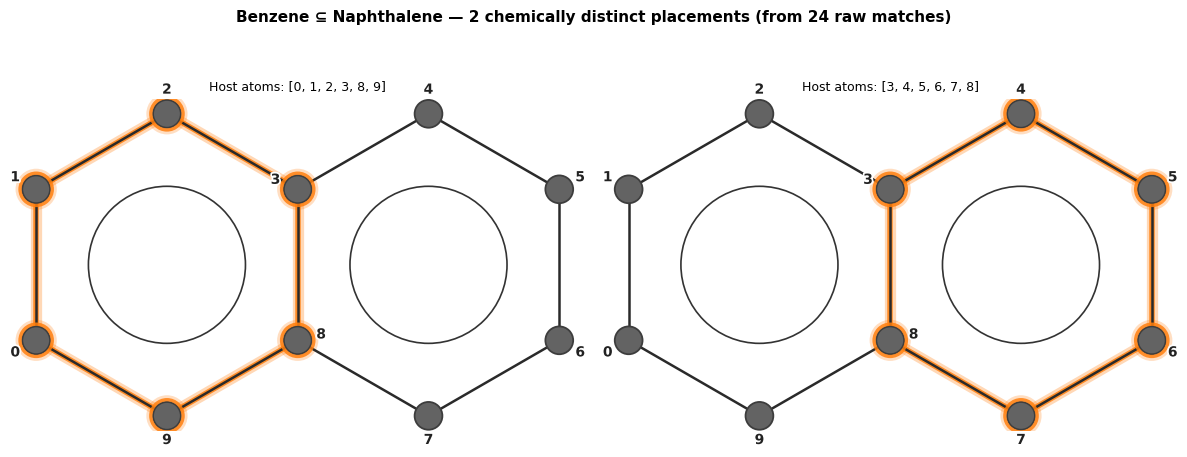

In [13]:
# Deduplicate to get the chemically distinct placements (2 benzene rings in naphthalene)
host_autos_ = enumerate_automorphisms(host_G)
host_orbits_ = compute_orbits_from_automorphisms(host_G, host_autos_)
reps = dedup_by_host_image_with_orbits(matches)  # 2 unique placements

print(f"Raw matches: {len(matches)}   →   Unique placements: {len(reps)}")

fig, axes = plt.subplots(1, len(reps), figsize=(6 * len(reps), 5))
fig.suptitle(
    f"Benzene ⊆ Naphthalene — {len(reps)} chemically distinct placements "
    f"(from {len(matches)} raw matches)",
    fontsize=11,
    fontweight="bold",
)

for ax, rep in zip(axes, reps):
    matched_host_nodes = set(rep.values())
    matched_host_edges = {
        (u, v)
        for u, v in host_G.edges()
        if u in matched_host_nodes and v in matched_host_nodes
    }
    draw_molecular_graph(
        host_G,
        mol=host_mol,
        ax=ax,
        label_mode="none",
        highlight_nodes=matched_host_nodes,
        highlight_edges=matched_host_edges,
        highlight_color="#FF7F0E",
        show_indices=True,
    )
    ax.set_title(f"Host atoms: {sorted(matched_host_nodes)}", fontsize=9)

plt.tight_layout()
plt.show()

### Deduplication — before / after

Raw match counts grow with molecular symmetry; deduplication by host-image collapses them to the number of **chemically distinct placements**.
The reduction factor equals $|\mathrm{Aut}(P)| \times$ (host symmetry multiplicity).

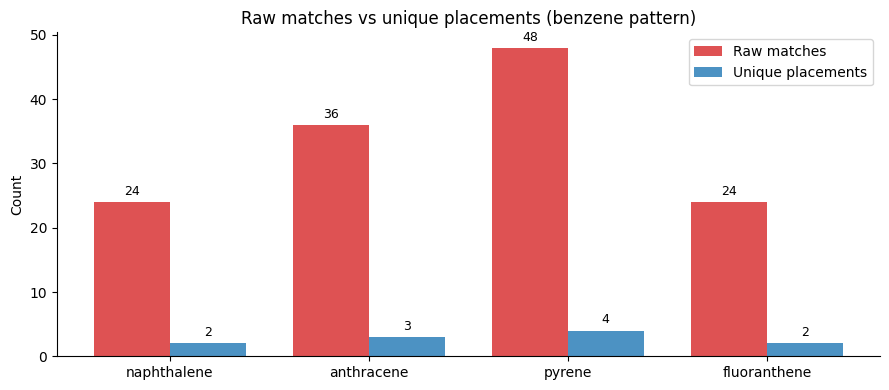

,host,raw,unique,reduction_factor
0,naphthalene,24,2,12
1,anthracene,36,3,12
2,pyrene,48,4,12
3,fluoranthene,24,2,12


In [14]:
from rdkit import Chem
from synedu.Utils import mol_to_graph
import matplotlib.pyplot as plt

_pattern_mol = Chem.MolFromSmiles("c1ccccc1")  # benzene as pattern
_pattern_G = mol_to_graph(_pattern_mol)

_hosts = [
    ("naphthalene", "c1ccc2ccccc2c1"),
    ("anthracene", "c1ccc2cc3ccccc3cc2c1"),
    ("pyrene", "c1cc2ccc3cccc4ccc(c1)c2c34"),
    ("fluoranthene", "c1ccc2-c3cccc4cccc-3c4c2c1"),
]

rows = []
for name, smi in _hosts:
    hmol = Chem.MolFromSmiles(smi)
    hG = mol_to_graph(hmol)
    raw = nx_subgraph_matches(hG, _pattern_G, invert=True)
    hautos = enumerate_automorphisms(hG)
    horbits = compute_orbits_from_automorphisms(hG, hautos)
    deduped = dedup_by_host_image_with_orbits(raw)
    rows.append((name, len(raw), len(deduped), len(raw) // max(len(deduped), 1)))

names, raws, dedups, factors = zip(*rows)
x = range(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(
    [i - w / 2 for i in x],
    raws,
    width=w,
    color="#D62728",
    alpha=0.8,
    label="Raw matches",
)
b2 = ax.bar(
    [i + w / 2 for i in x],
    dedups,
    width=w,
    color="#1F77B4",
    alpha=0.8,
    label="Unique placements",
)
ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Raw matches vs unique placements (benzene pattern)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

import pandas as pd

pd.DataFrame(
    {"host": names, "raw": raws, "unique": dedups, "reduction_factor": factors}
)

**Q4 — Deduplicate modulo pattern automorphisms**

Implement a function `dedup_by_pattern_image_with_orbits(matches, pattern_autos, ...)` that groups/filters pattern→host mappings **modulo pattern automorphisms**.

Intuitively, two mappings
$$
m_1,\, m_2 : P \to H
$$
are **equivalent** if there exists a pattern automorphism
$$
\varphi \in \mathrm{Aut}(P)
$$
such that
$$
m_2 \;=\; m_1 \circ \varphi .
$$

Equivalently, the two mappings differ only by a **permutation of the pattern
nodes**, induced by an automorphism of the pattern graph.


<details> <summary><b>Solution:</b></summary>

```python
from collections import defaultdict
from typing import Dict, Iterable, List, Tuple, Optional, Union

def dedup_by_pattern_image_with_orbits(
    matches: Iterable[Dict[int,int]],
    *,
    pattern_autos: Iterable[Dict[int,int]],
    pattern_node_order: Optional[Iterable[int]] = None,
    return_groups: bool = False,
) -> Union[List[Dict[int,int]], Dict[Tuple[int,...], List[Dict[int,int]]]]:
    matches = list(matches)
    if not matches:
        return {} if return_groups else []

    # deterministic pattern node order
    if pattern_node_order is None:
        pattern_node_order = tuple(sorted(matches[0].keys()))
    else:
        pattern_node_order = tuple(pattern_node_order)

    # pre-list autos for repeated use
    autos = list(pattern_autos)

    # helper: canonical tuple for mapping m under all pattern automorphisms
    def canonical_tuple_for_mapping(m: Dict[int,int]) -> Tuple[int, ...]:
        best = None
        for phi in autos:
            tup = tuple(m[phi[p]] for p in pattern_node_order)
            if best is None or tup < best:
                best = tup
        return best

    # bucket by canonical tuple
    buckets: Dict[Tuple[int,...], List[Dict[int,int]]] = defaultdict(list)
    for m in matches:
        key = canonical_tuple_for_mapping(m)
        buckets[key].append(m)

    # deterministic ordering of keys
    ordered_keys = sorted(buckets.keys())

    if return_groups:
        return {k: buckets[k] for k in ordered_keys}

    # select deterministic representative per bucket:
    # pick mapping with smallest tuple according to pattern_node_order
    def ordering_tuple(m: Dict[int,int]) -> Tuple[int, ...]:
        return tuple(m[p] for p in pattern_node_order)

    representatives: List[Dict[int,int]] = []
    for k in ordered_keys:
        group = buckets[k]
        rep = min(group, key=ordering_tuple)
        representatives.append(rep)

    return representatives

```

**Q5 — Detect ethanol as a subgraph in a molecule table**

**Goal.**  
Given a table of molecules represented by SMILES strings, determine which
molecules contain **ethanol** as a subgraph, and store the result in a new
boolean column `is_subgraph_ethanol`.

This exercise connects **subgraph isomorphism** with a practical,
dataframe-based workflow.

---

**Tasks**

1. **Convert SMILES to RDKit molecules**  
   Create a column `mol` by parsing the SMILES strings with RDKit.

2. **Convert molecules to labeled graphs**  
   Create a column `graph` by converting each RDKit molecule to a
   NetworkX graph using `mol_to_graph`.

3. **Select ethanol as the pattern graph**  
   Use the graph of ethanol (row 0) as the subgraph pattern.

4. **Test subgraph containment**  
   For each molecule, check whether the ethanol graph is a subgraph of
   the molecule graph using `nx_subgraph_matches`.

5. **Store the result**  
   Add a boolean column `is_subgraph_ethanol` indicating whether at least
   one subgraph embedding exists.


<details> <summary><b>Solution:</b></summary>

```python
from rdkit import Chem

# 1. Convert SMILES to RDKit molecules
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

# 2. Convert molecules to labeled NetworkX graphs
df["graph"] = df["mol"].apply(mol_to_graph)

# 3. Select ethanol as the pattern graph
ethanol_G = df.loc[0, "graph"]

# 4. Subgraph test: ethanol ⊆ host
def has_ethanol_subgraph(host_G):
    matches = nx_subgraph_matches(
        host_G=host_G,
        pattern_G=ethanol_G,
        invert=True,  # pattern_idx -> host_idx
    )
    return len(matches) > 0

# 5. Add boolean result column
df["is_subgraph_ethanol"] = df["graph"].apply(has_ethanol_subgraph)

```

### 3.3. RDKit subgraph search


RDKit performs pattern-in-host queries via **substructure matching**:

```python
host_mol.GetSubstructMatches(pattern_mol)
```
Each returned match is a mapping **pattern atom index → host atom index**.

**Practical limitations:**
- Atom indices are fixed by RDKit’s internal molecule ordering and cannot be
  freely relabeled or manipulated.
- Node/edge matching criteria are not user-definable; they are hard-coded into
  RDKit’s chemistry model.
- Automorphisms and orbit structure are not exposed, making symmetry handling implicit.
- Fine-grained control over which atom or bond attributes participate in matching
  is limited compared to explicit graph-based approaches.

As a result, RDKit substructure matching is efficient and chemically robust,
but less flexible for algorithmic experimentation and symmetry-aware workflows.


In [15]:
from rdkit import Chem
from typing import List, Dict, Tuple


def rdkit_subgraph_matches(
    host_mol: Chem.Mol,
    pattern_mol: Chem.Mol,
    *,
    uniquify: bool = False,
) -> List[Dict[int, int]]:
    """
    Enumerate substructure matches of `pattern_mol` inside `host_mol`.

    Returns
    -------
    List[Dict[int, int]]
        Each mapping is: pattern_atom_idx -> host_atom_idx

    Notes
    -----
    - RDKit returns tuples of host indices ordered by pattern atom order.
    - If `uniquify=False`, symmetry-equivalent embeddings are *not* removed.
    """
    matches: Tuple[Tuple[int, ...], ...] = host_mol.GetSubstructMatches(
        pattern_mol,
        uniquify=uniquify,
    )

    out: List[Dict[int, int]] = []
    for m in matches:
        out.append({p_idx: h_idx for p_idx, h_idx in enumerate(m)})
    return out


# Compare raw vs heuristic-deduplicated matches
matches = rdkit_subgraph_matches(host_mol, pattern_mol, uniquify=False)
print("Raw subgraph isomorphisms (pattern → host):", len(matches))

matches = rdkit_subgraph_matches(host_mol, pattern_mol, uniquify=True)
print("Heuristically unique subgraph isomorphisms (pattern → host):", len(matches))

Raw subgraph isomorphisms (pattern → host): 24
Heuristically unique subgraph isomorphisms (pattern → host): 2


### RDKit vs NetworkX matching comparison

Applying both matchers to a common test set (ethanol pattern across six host molecules) lets us verify that orbit-based deduplication matches RDKit's `uniquify=True` result, and flag any edge cases where the two frameworks disagree.

In [16]:
from rdkit import Chem
import pandas as pd

_pattern_smi = "CCO"  # ethanol
_pattern_mol_rdkit = Chem.MolFromSmiles(_pattern_smi)
_pattern_G_nx = mol_to_graph(_pattern_mol_rdkit)

_test_cases = [
    ("naphthalene", "c1ccc2ccccc2c1"),
    ("aspirin", "CC(=O)Oc1ccccc1C(=O)O"),
    ("diethyl ether", "CCOCC"),
    ("ethanol", "CCO"),
    ("propanol", "CCCO"),
    ("glycol", "OCCO"),
]

rows = []
for name, smi in _test_cases:
    hmol = Chem.MolFromSmiles(smi)
    hG = mol_to_graph(hmol)

    nx_raw = nx_subgraph_matches(hG, _pattern_G_nx, invert=True)
    nx_deduped = dedup_by_host_image_with_orbits(nx_raw)

    rdkit_raw = rdkit_subgraph_matches(hmol, _pattern_mol_rdkit, uniquify=False)
    rdkit_uniq = rdkit_subgraph_matches(hmol, _pattern_mol_rdkit, uniquify=True)

    rows.append(
        {
            "molecule": name,
            "NX raw": len(nx_raw),
            "NX deduplicated": len(nx_deduped),
            "RDKit raw": len(rdkit_raw),
            "RDKit uniquify": len(rdkit_uniq),
            "NX==RDKit unique": len(nx_deduped) == len(rdkit_uniq),
        }
    )

df_cmp = pd.DataFrame(rows).set_index("molecule")
display(
    df_cmp.style.applymap(
        lambda v: (
            "color:green;font-weight:bold"
            if v is True
            else "color:red;font-weight:bold" if v is False else ""
        ),
        subset=["NX==RDKit unique"],
    ).set_caption("Ethanol subgraph — NX vs RDKit match counts")
)

/tmp/ipykernel_158713/3154709094.py:41: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_cmp.style.applymap(


,NX raw,NX deduplicated,RDKit raw,RDKit uniquify,NX==RDKit unique
molecule,,,,,
naphthalene,0,0,0,0,True
aspirin,4,4,2,2,False
diethyl ether,2,2,2,2,True
ethanol,1,1,1,1,True
propanol,1,1,1,1,True
glycol,2,2,2,2,True


**Q6 — Detect ethanol subgraphs using RDKit and compare with NetworkX**

**Goal.**  
Repeat **Q5** using **RDKit substructure matching** instead of NetworkX,
and compare the resulting boolean column with the NetworkX-based result.

This exercise highlights practical differences between:
- explicit graph-based subgraph isomorphism (NetworkX), and
- chemistry-native substructure matching (RDKit).

---

**Step-by-step tasks**

0. **Reuse the RDKit molecule column**  
   Use the existing `mol` column created from SMILES.

1. **Select ethanol as the pattern molecule**  
   Use the RDKit molecule corresponding to ethanol (row 0).

2. **Test RDKit substructure containment**  
   For each molecule, check whether RDKit finds at least one substructure
   match of ethanol using `GetSubstructMatches`.

3. **Store the result**  
   Add a boolean column `is_subgraph_ethanol_rdkit`.

4. **Compare with the NetworkX result**  
   Identify molecules where RDKit and NetworkX disagree.


<details> <summary><b>Solution:</b></summary>


```python
from rdkit import Chem

# 1. Select ethanol as RDKit pattern molecule
ethanol_mol = df.loc[0, "mol"]

# 2. RDKit-based subgraph test
def has_ethanol_subgraph_rdkit(host_mol):
    matches = rdkit_subgraph_matches(
        host_mol=host_mol,
        pattern_mol=ethanol_mol,
        uniquify=True,
    )
    return len(matches) > 0

# 3. Add RDKit result column
df["is_subgraph_ethanol_rdkit"] = df["mol"].apply(has_ethanol_subgraph_rdkit)

# 4. Comparison
comparison = df[
    df["is_subgraph_ethanol"] != df["is_subgraph_ethanol_rdkit"]
][["smiles", "name", "is_subgraph_ethanol", "is_subgraph_ethanol_rdkit"]]

comparison
```

## 4. Discussion

- **Graph automorphisms** encode molecular symmetry. Unchecked, they inflate
  match enumeration and lead to redundant computation. Orbit-aware
  deduplication (e.g. by host-atom sets or orbit representatives) converts
  symmetry from a liability into a computational advantage.

- **Subgraph isomorphism** is the core operation for rule application later in SynEdu.
- **MCS** is a chemistry-aware alignment primitive, but it is heuristic and sometimes non-unique; always log settings and timeouts.
- **RDKit vs NetworkX**:
  - RDKit: SMARTS matching, built-in `uniquify`.
  - NetworkX: full control over attributes and morphism semantics; you manage deduplication and interpretation.

## 5. Quiz

Answer the following questions using **both chemical intuition** and **formal
graph-theoretic language**. When appropriate, describe your answer in terms of
**graph morphisms**, **automorphism groups**, and **equivalence classes**.

---

### 1. Isomorphism  
What **additional requirement** must a graph morphism
$$
f : G \to H
$$
satisfy in order to be an **isomorphism**?

- How does bijectivity relate to the statement  
  *“two molecules have the same structure”*?
- What chemical information (atom types, bond orders) must be preserved?

---

### 2. Automorphisms and symmetry  
What is an **automorphism** of a molecular graph?

- Formally, how is an automorphism defined as a map
  $$
  \varphi : G \to G \, ?
  $$
- Why do highly symmetric molecules (e.g. benzene) have a **large**
  automorphism group
  $$
  \mathrm{Aut}(G) \, ?
  $$
- Explain why the existence of non-trivial automorphisms leads to
  **multiple equivalent subgraph matches** during pattern matching.

---

### 3. Deduplicating subgraph matches  
Subgraph matching algorithms often return many **equivalent morphisms**.

- Explain how representing a match by the **set of host atom indices**
  $$
  \{\, m(v) \mid v \in V(P) \,\}
  $$
  can be used to **deduplicate** equivalent matches.
- Why does this strategy work even when the mappings differ by a permutation
  of pattern nodes?


## 6. References

1. <a id="ref-1"></a> RDKit documentation: https://www.rdkit.org/docs/  
2. <a id="ref-2"></a> NetworkX documentation: https://networkx.org/documentation/stable/
3. <a id="ref-3"></a> Bonchev, D., & Rouvray, D. H. (eds.).  
   *Chemical Graph Theory: Introduction and Fundamentals*.  
   Abacus Press, 1991.  
   ISBN: 978-0856267588  
   — Classic reference linking molecular graphs, symmetry, and
   **automorphism groups** to chemical interpretation.

4. <a id="ref-4"></a> Diestel, R.  
   *Graph Theory* (5th ed.).  
   Springer, 2017.  
   DOI: 10.1007/978-3-662-53622-3  
   — Authoritative mathematical treatment of **graph morphisms**,
   **isomorphisms**, **automorphisms**, and group actions on graphs.
